In [1]:
import rioxarray as rxr
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [57]:
s2_dnbr_dir = r'/Volumes/PhD/imagery/masters/output/dNBR/'

av_HM1_dir = r'/Volumes/PhD/imagery/masters/output/hyper_compare/HM1/'
av_OHM1_dir = r'/Volumes/PhD/imagery/masters/output/hyper_compare/OHM1/'
nbr_dir = r'/Volumes/PhD/imagery/masters/output/NBR/'

basin = '19165'

out = r'/Volumes/PhD/imagery/masters/output/hyper_compare/landslides_edits/SI/'

In [58]:
M1_dnbr = rxr.open_rasterio(s2_dnbr_dir + f'basin_{basin}_dNBR.tif', masked=True).squeeze()
HM1_dnbr = rxr.open_rasterio(av_HM1_dir + f'Basin_{basin}_dNBR.tif', masked=True).squeeze()
OHM1_dnbr = rxr.open_rasterio(av_OHM1_dir + f'Basin_{basin}_dNBR.tif', masked=True).squeeze()

M1_nbr_pre = rxr.open_rasterio(nbr_dir + f'{basin}_S2_NBR_pre.tif', masked=True).squeeze()
M1_nbr_post = rxr.open_rasterio(nbr_dir + f'{basin}_S2_NBR_post.tif', masked=True).squeeze()

HM1_nbr_pre = rxr.open_rasterio(nbr_dir + f'{basin}_HM1_AV_NBR_pre.tif', masked=True).squeeze()
HM1_nbr_post = rxr.open_rasterio(nbr_dir + f'{basin}_HM1_AV_NBR_post.tif', masked=True).squeeze()

OHM1_nbr_pre = rxr.open_rasterio(nbr_dir + f'{basin}_OHM1_AV_NBR_pre.tif', masked=True).squeeze()
OHM1_nbr_post = rxr.open_rasterio(nbr_dir + f'{basin}_OHM1_AV_NBR_post.tif', masked=True).squeeze()

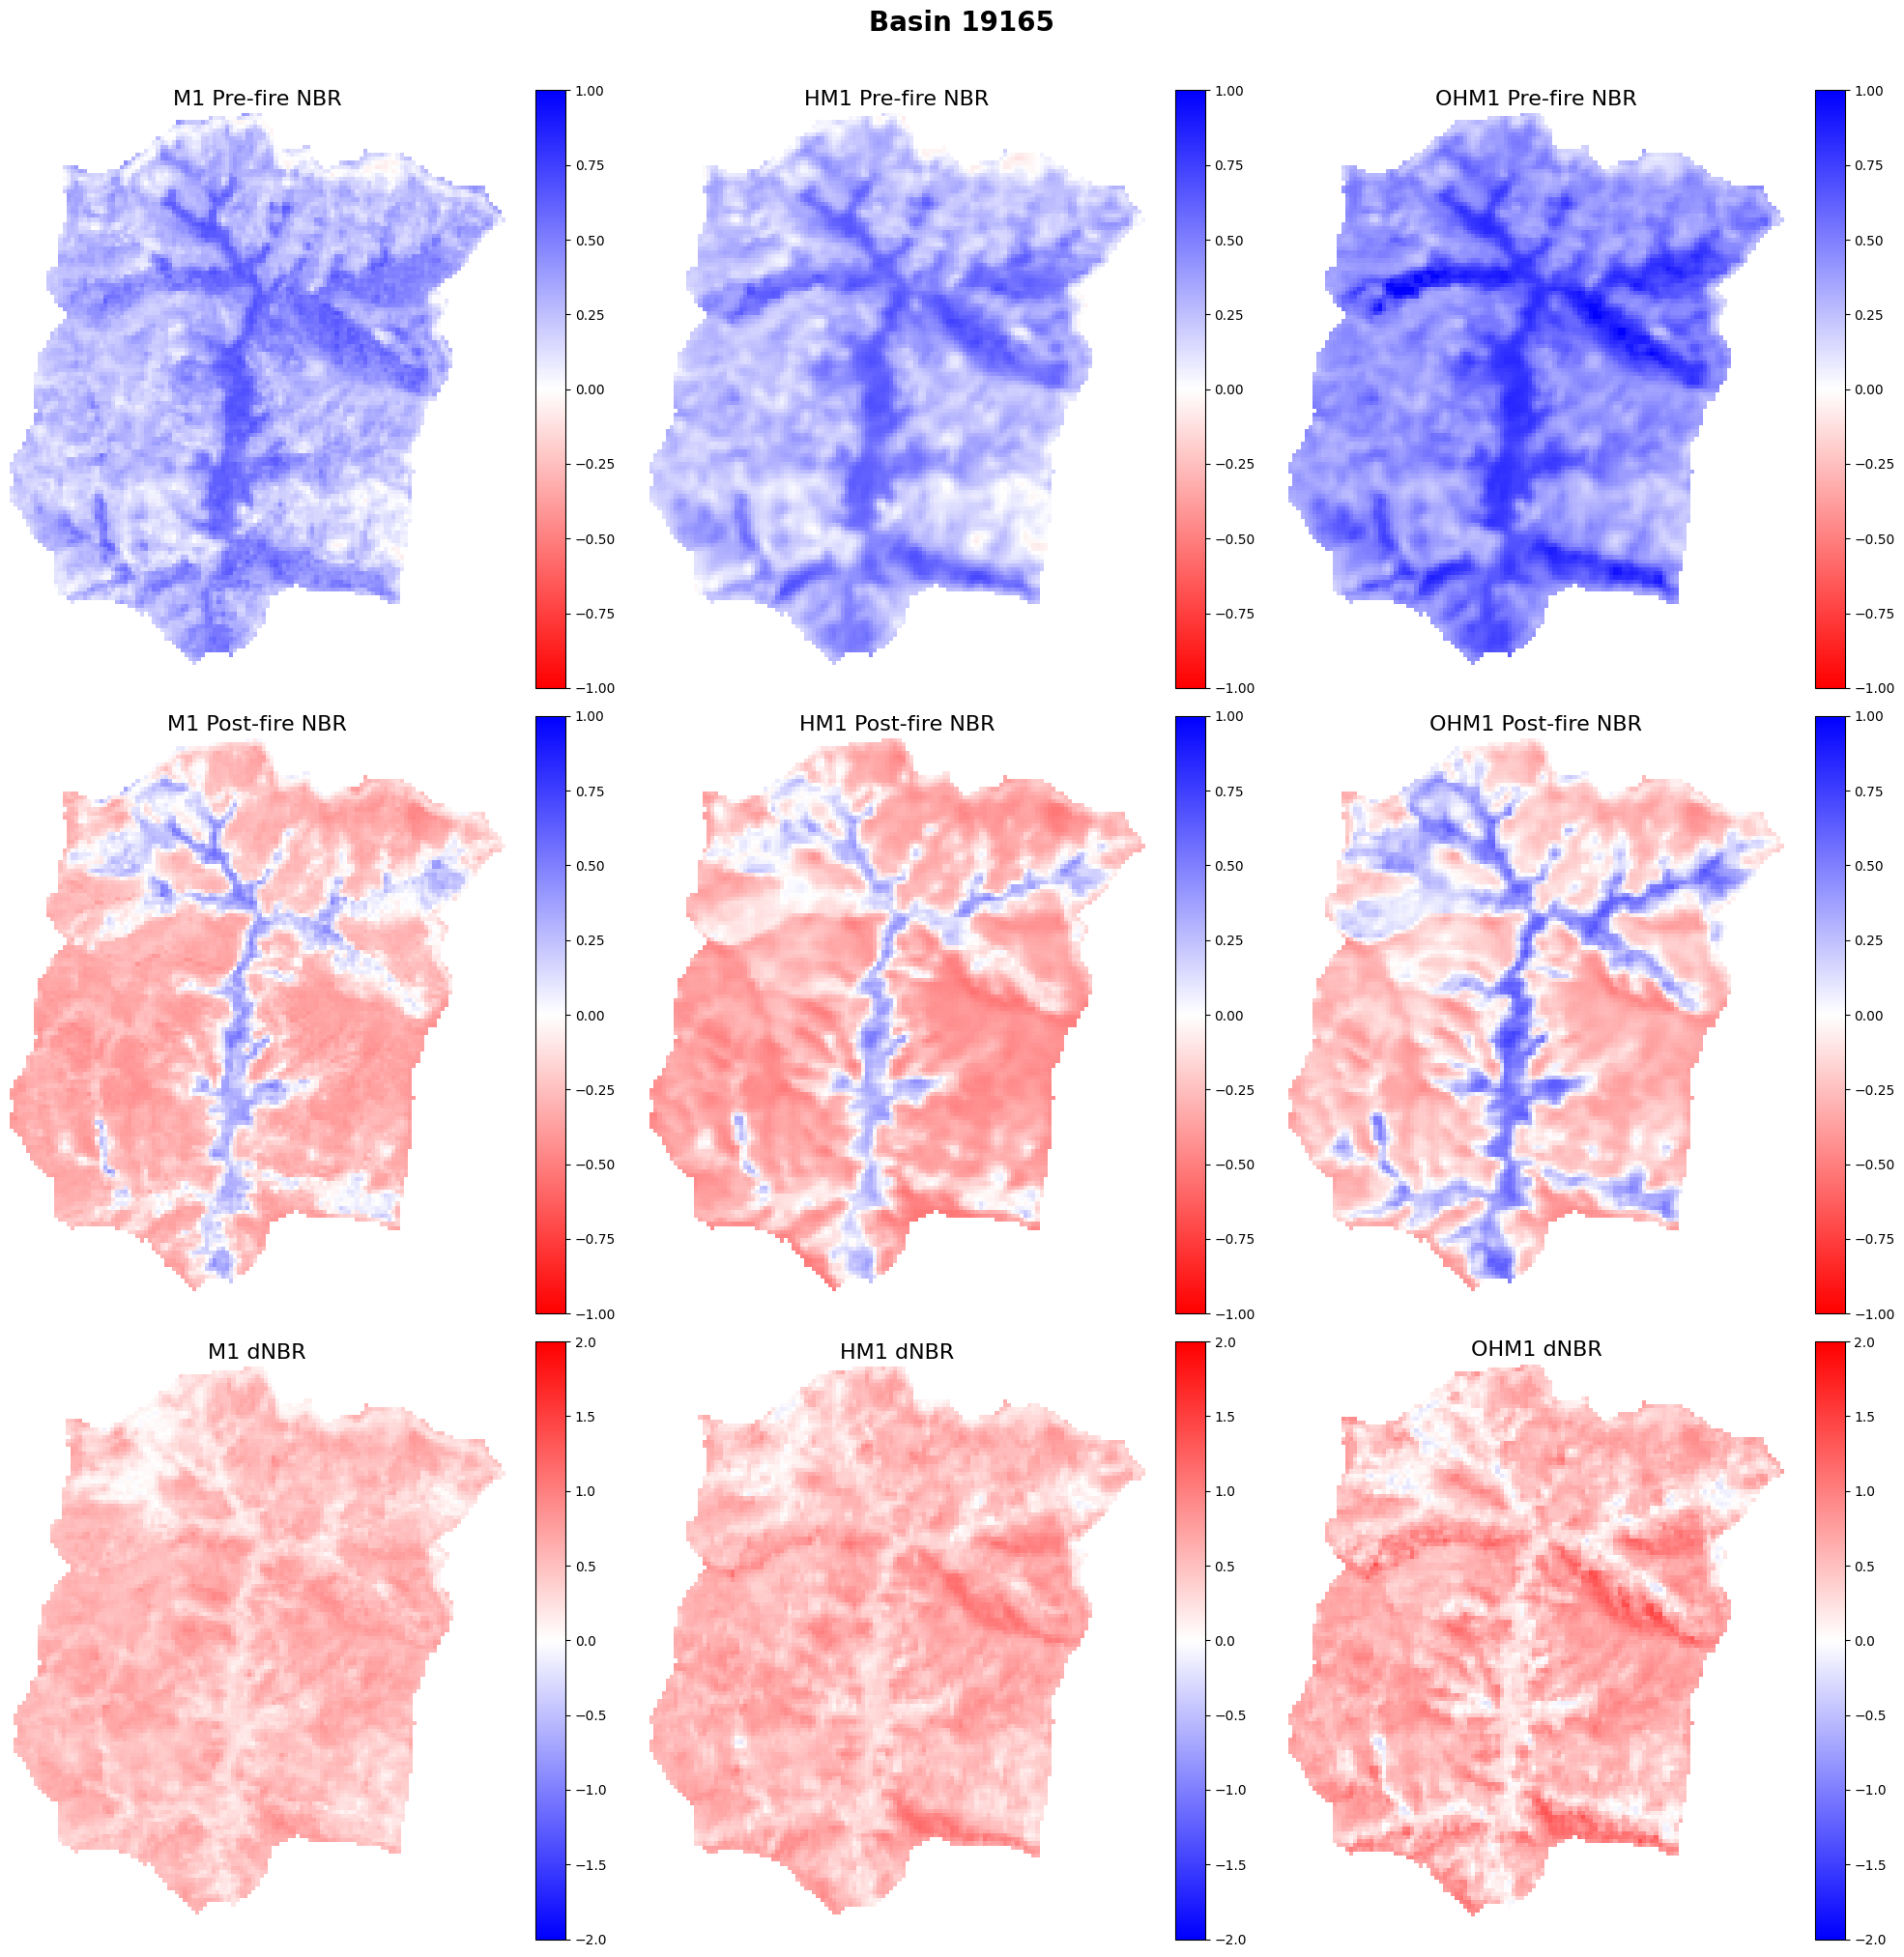

In [59]:
vmin = -1
vmax = 1
vmin_dnbr = -2
vmax_dnbr = 2

fig, axes = plt.subplots(3, 3, figsize=(20, 20))

# Row 1 Pre-fire NBR
im = axes[0, 0].imshow(M1_nbr_pre, cmap='bwr_r', vmin=vmin, vmax=vmax)
fig.colorbar(im, ax=axes[0, 0])
axes[0, 0].set_title('M1 Pre-fire NBR', fontsize=16)

im = axes[0, 1].imshow(HM1_nbr_pre, cmap='bwr_r', vmin=vmin, vmax=vmax)
fig.colorbar(im, ax=axes[0, 1])
axes[0, 1].set_title('HM1 Pre-fire NBR', fontsize=16)

im = axes[0, 2].imshow(OHM1_nbr_pre, cmap='bwr_r', vmin=vmin, vmax=vmax)
fig.colorbar(im, ax=axes[0, 2])
axes[0, 2].set_title('OHM1 Pre-fire NBR', fontsize=16)

# Row 2 Post-fire NBR
im = axes[1, 0].imshow(M1_nbr_post, cmap='bwr_r', vmin=vmin, vmax=vmax)
fig.colorbar(im, ax=axes[1, 0])
axes[1, 0].set_title('M1 Post-fire NBR', fontsize=16)   

im = axes[1, 1].imshow(HM1_nbr_post, cmap='bwr_r', vmin=vmin, vmax=vmax)
fig.colorbar(im, ax=axes[1, 1])
axes[1, 1].set_title('HM1 Post-fire NBR', fontsize=16)

im = axes[1, 2].imshow(OHM1_nbr_post, cmap='bwr_r', vmin=vmin, vmax=vmax)
fig.colorbar(im, ax=axes[1, 2])
axes[1, 2].set_title('OHM1 Post-fire NBR', fontsize=16)

# Row 3 dNBR
im = axes[2, 0].imshow(M1_dnbr, cmap='bwr', vmin=vmin_dnbr, vmax=vmax_dnbr)
fig.colorbar(im, ax=axes[2, 0])
axes[2, 0].set_title('M1 dNBR', fontsize=16)

im = axes[2, 1].imshow(HM1_dnbr, cmap='bwr', vmin=vmin_dnbr, vmax=vmax_dnbr)
fig.colorbar(im, ax=axes[2, 1])
axes[2, 1].set_title('HM1 dNBR', fontsize=16)

im = axes[2, 2].imshow(OHM1_dnbr, cmap='bwr', vmin=vmin_dnbr, vmax=vmax_dnbr)
fig.colorbar(im, ax=axes[2, 2])
axes[2, 2].set_title('OHM1 dNBR', fontsize=16)
for ax in axes.flatten():
    ax.axis('off')
plt.suptitle(f'Basin {basin}', fontsize=20, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(out + f'Basin_{basin}_NBR_dNBR_comparison.png', dpi=600, bbox_inches='tight')
plt.show()


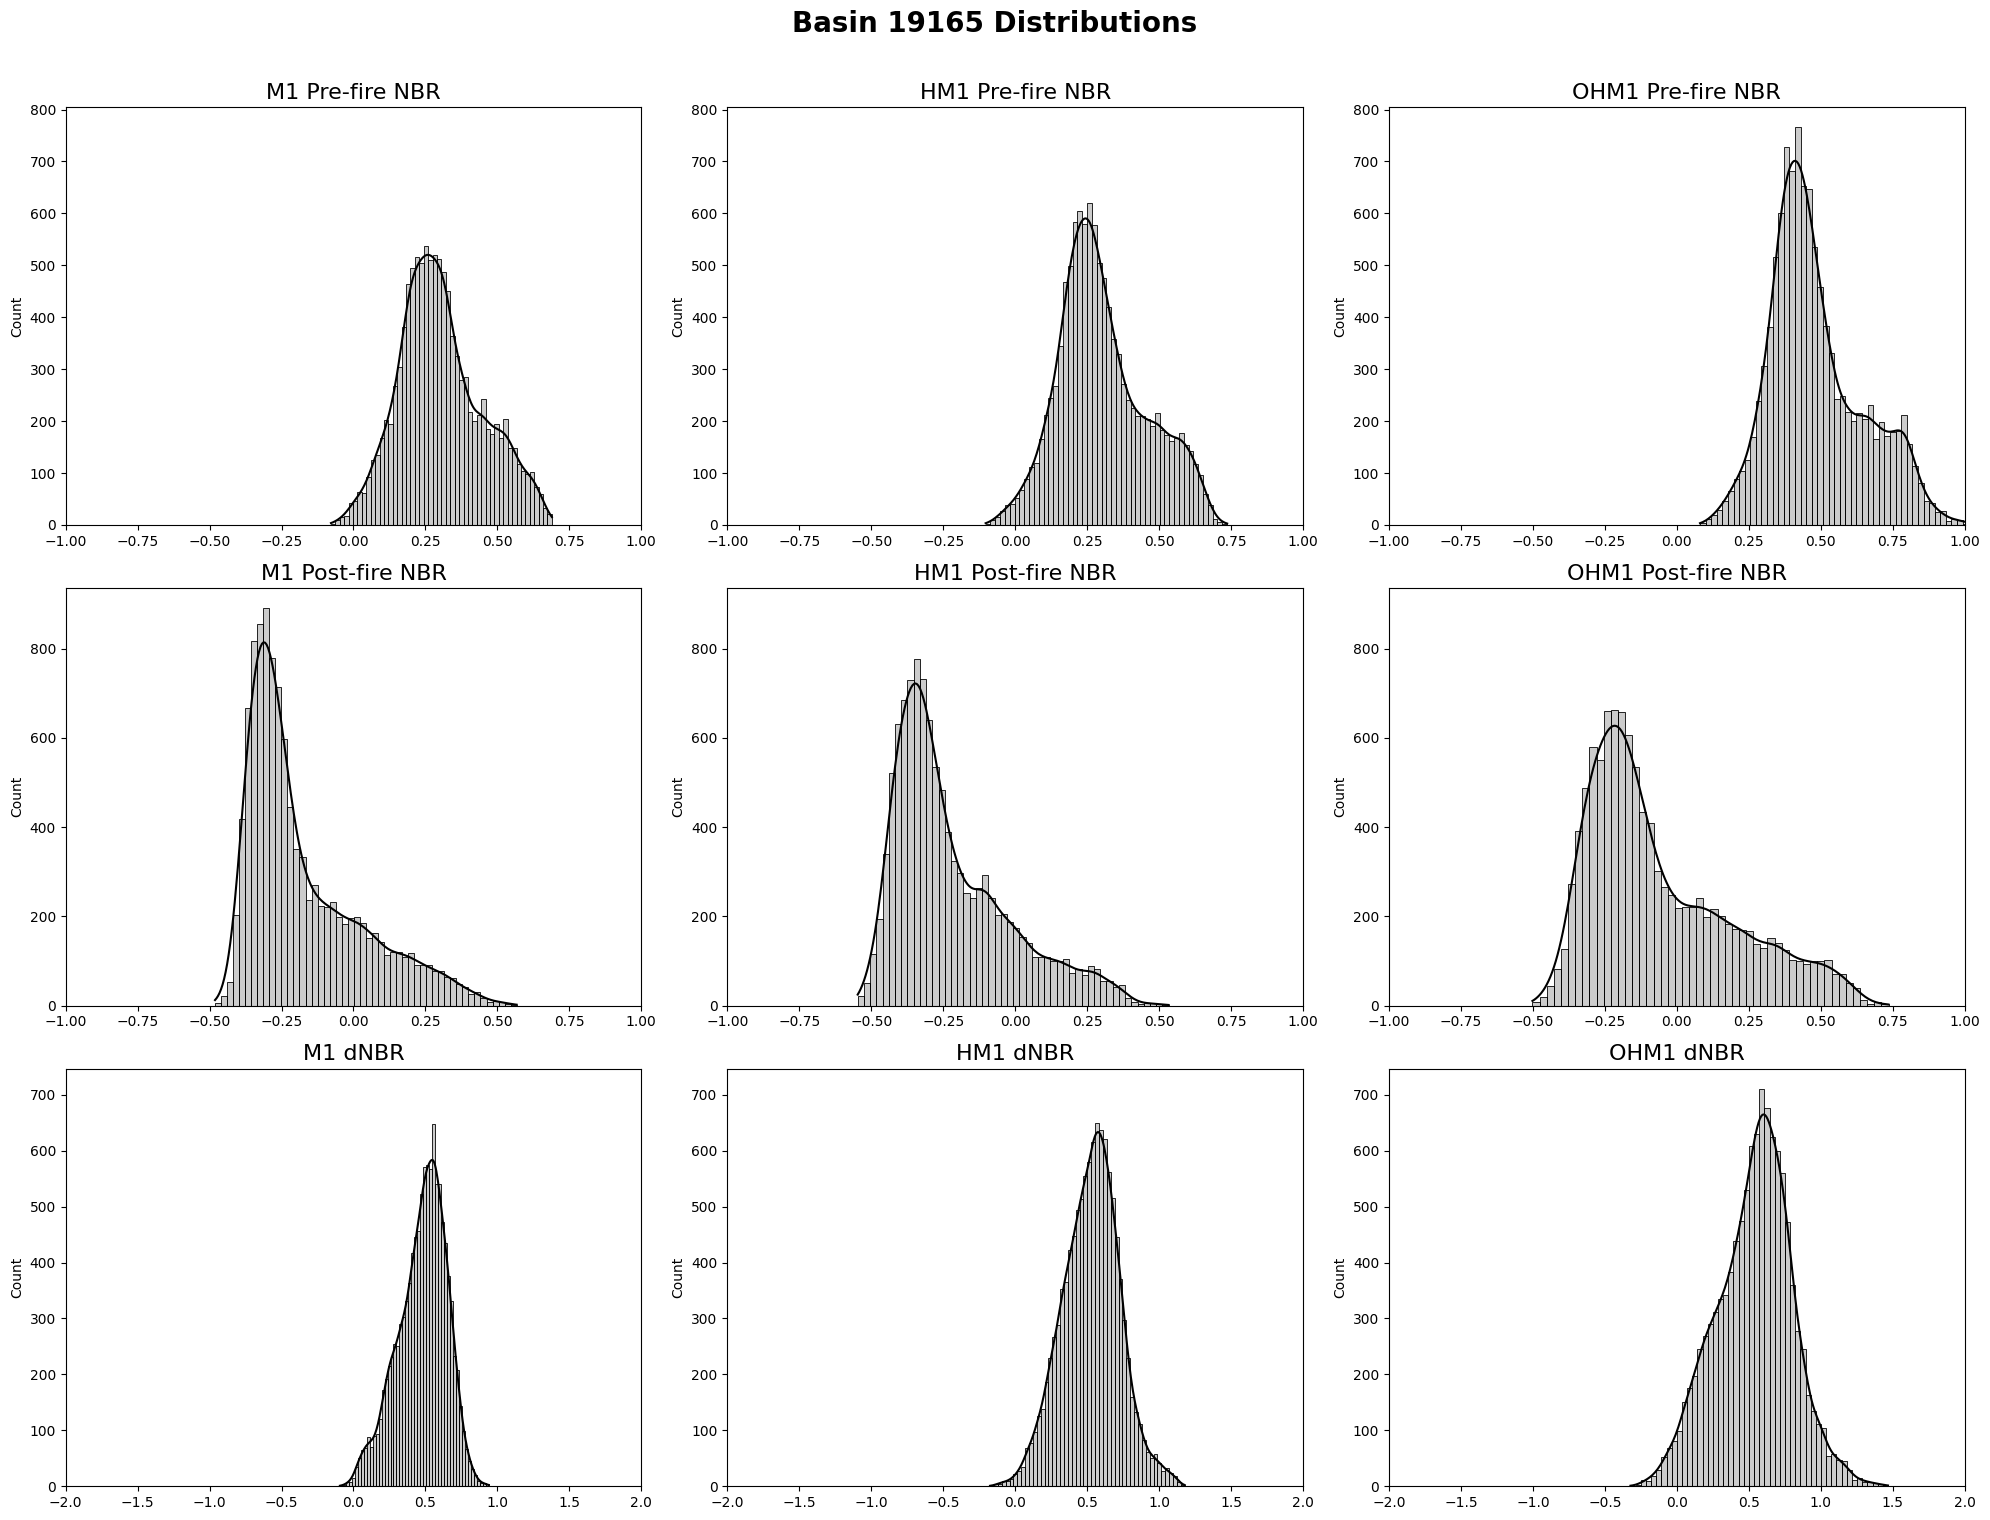

In [60]:
# Plot a 3x3 grid of histograms with titles

fig, axes = plt.subplots(3, 3, figsize=(20, 15))

sns.histplot(M1_nbr_pre.values.flatten(), bins=50, color='black', kde=True, alpha=0.2, ax=axes[0, 0])
axes[0, 0].set_title('M1 Pre-fire NBR', fontsize=16)

sns.histplot(HM1_nbr_pre.values.flatten(), bins=50, color='black', kde=True, alpha=0.2, ax=axes[0, 1])
axes[0, 1].set_title('HM1 Pre-fire NBR', fontsize=16)

sns.histplot(OHM1_nbr_pre.values.flatten(), bins=50, color='black', kde=True, alpha=0.2, ax=axes[0, 2])
axes[0, 2].set_title('OHM1 Pre-fire NBR', fontsize=16)

sns.histplot(M1_nbr_post.values.flatten(), bins=50, color='black', kde=True, alpha=0.2, ax=axes[1, 0])
axes[1, 0].set_title('M1 Post-fire NBR', fontsize=16)

sns.histplot(HM1_nbr_post.values.flatten(), bins=50, color='black', kde=True, alpha=0.2, ax=axes[1, 1])
axes[1, 1].set_title('HM1 Post-fire NBR', fontsize=16)

sns.histplot(OHM1_nbr_post.values.flatten(), bins=50, color='black', kde=True, alpha=0.2, ax=axes[1, 2])
axes[1, 2].set_title('OHM1 Post-fire NBR', fontsize=16)

sns.histplot(M1_dnbr.values.flatten(), bins=50, color='black', kde=True, alpha=0.2, ax=axes[2, 0])
axes[2, 0].set_title('M1 dNBR', fontsize=16)    

sns.histplot(HM1_dnbr.values.flatten(), bins=50, color='black', kde=True, alpha=0.2, ax=axes[2, 1])
axes[2, 1].set_title('HM1 dNBR', fontsize=16)

sns.histplot(OHM1_dnbr.values.flatten(), bins=50, color='black', kde=True, alpha=0.2, ax=axes[2, 2])
axes[2, 2].set_title('OHM1 dNBR', fontsize=16)

# Row 1 & 2 → NBR
for i in [0, 1]:
    for ax in axes[i, :]:
        ax.set_xlim(-1, 1)

# Row 3 → dNBR
for ax in axes[2, :]:
    ax.set_xlim(-2, 2)
    
for i in range(3):
    row_axes = axes[i, :]
    
    ymax = max(
        max([p.get_height() for p in ax.patches], default=[0])
        for ax in row_axes
    )
    
    for ax in row_axes:
        ax.set_ylim(0, ymax * 1.05)

plt.suptitle(f'Basin {basin} Distributions', fontsize=20, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(out + f'Basin_{basin}_distributions_comparison.png', dpi=600, bbox_inches='tight')
plt.show()